# Post processing and visualizing mandyoc data

The following notebook allows the user to reproduce Figures 8 and 9.

In [1]:
#increase the display size to 95% of window width
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
display(HTML("<style>.output_result { max-width:95% !important; }</style>"))


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import glob
import os
import sys
import pylab as pl
import xarray as xr
import pymp
import mpl_toolkits.axisartist
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
import string

local_path = os.getcwd()

sys.path.insert(0, f"{local_path}/functions")
from mandyocIO import read_datasets, change_dataset, plot_property, find_nearest, plot_tracked_particles, _extract_interface,  plot_tracked_particles_depth_coded

# How to plot

## In the following cell, you must inform:
 - Which Figure you wish to plot by comment/uncomment the `fig_to_plot` options

In [17]:
# fig_to_plot = 'Fig8'
fig_to_plot = 'Fig9'

#Set scenario path
scenarios_path = local_path.split('/')
scenarios_path = f"{'/'.join(scenarios_path[:-1])}/scenarios"

if(fig_to_plot=='Fig8'):
    scenarios = [
                f"{scenarios_path}/1w_Ho35W1",
                f"{scenarios_path}/4w_Ho35W2",
                f"{scenarios_path}/7w_Ho35W3",

                f"{scenarios_path}/2w_He35W1",
                f"{scenarios_path}/5w_He35W2",
                f"{scenarios_path}/8w_He35W3",


                f"{scenarios_path}/3w_Ho40W1",
                f"{scenarios_path}/6w_Ho40W2",
                f"{scenarios_path}/9w_Ho40W3",                
                ]
    clc = 1
    
if(fig_to_plot=='Fig9'):
    scenarios = [
                f"{scenarios_path}/1s_Ho35S1",
                f"{scenarios_path}/4s_Ho35S2",
                f"{scenarios_path}/7s_Ho35S3",

                f"{scenarios_path}/2s_He35S1",
                f"{scenarios_path}/5s_He35S2",
                f"{scenarios_path}/8s_He35S3",


                f"{scenarios_path}/3s_Ho40S1",
                f"{scenarios_path}/6s_Ho40S2",
                f"{scenarios_path}/9s_Ho40S3",                
                ]
    clc = 10

print(f"Plotting scenarios with Clc={clc} for different rifting velocities.")
                

plot_isotherms = True

if(plot_isotherms):
    clean_plot=False
else:
    clean_plot = True

datasets = [#Properties from mandyoc. Comment/uncomment to select properties of the dataset
            'density',
            'radiogenic_heat',
            'pressure',
            'strain',
            'strain_rate',### Read ascii outputs and save them as xarray.Datasets,
            'surface',
            'temperature',
            'viscosity'
            ]# Read data and convert them to xarray.Dataset

properties = [#Properties from mandyoc. Comment/uncomment to select which ones you would like to plot
            #  'density',
#              'radiogenic_heat',
             'lithology',
#              'pressure',
            #  'strain',
            #  'strain_rate',
            #  'temperature',
            #  'temperature_anomaly',
            #  'surface',
            #  'viscosity'
             ]

# Read ascii outputs and save them as xarray.Datasets

new_datasets = change_dataset(properties, datasets)

to_remove = []
remove_density=False
if ('density' not in properties): #used to plot air/curst interface
        properties.append('density')
        new_datasets = change_dataset(properties, datasets)
        to_remove.append('density')
        # remove_density=True

if ('surface' not in properties): #used to plot air/curst interface
        properties.append('surface')
        new_datasets = change_dataset(properties, datasets)
        to_remove.append('surface')
        # remove_density=True

if (plot_isotherms): #add datasets needed to plot isotherms
    if ('temperature' not in new_datasets):
        properties.append('temperature')
        new_datasets = change_dataset(properties, datasets)
        to_remove.append('temperature')

if(clean_plot): #a clean plot
    new_datasets = change_dataset(properties, datasets)

for item in to_remove:
    properties.remove(item)

dataset0 = read_datasets(scenarios[0], new_datasets)
dataset1 = read_datasets(scenarios[1], new_datasets)
dataset2 = read_datasets(scenarios[2], new_datasets)
dataset3 = read_datasets(scenarios[3], new_datasets)
dataset4 = read_datasets(scenarios[4], new_datasets)
dataset5 = read_datasets(scenarios[5], new_datasets)
dataset6 = read_datasets(scenarios[6], new_datasets)
dataset7 = read_datasets(scenarios[7], new_datasets)
dataset8 = read_datasets(scenarios[8], new_datasets)

# Normalize velocity values
if ("velocity_x" and "velocity_z") in dataset0.data_vars:
    v_max = np.max((dataset0.velocity_x**2 + dataset0.velocity_z**2)**(0.5))    
    dataset0.velocity_x[:] = dataset0.velocity_x[:] / v_max
    dataset0.velocity_z[:] = dataset0.velocity_z[:] / v_max

if ("velocity_x" and "velocity_z") in dataset1.data_vars:
    v_max = np.max((dataset1.velocity_x**2 + dataset1.velocity_z**2)**(0.5))    
    dataset1.velocity_x[:] = dataset1.velocity_x[:] / v_max
    dataset1.velocity_z[:] = dataset1.velocity_z[:] / v_max

if ("velocity_x" and "velocity_z") in dataset2.data_vars:
    v_max = np.max((dataset2.velocity_x**2 + dataset2.velocity_z**2)**(0.5))    
    dataset2.velocity_x[:] = dataset2.velocity_x[:] / v_max
    dataset2.velocity_z[:] = dataset2.velocity_z[:] / v_max


Nx = int(dataset0.nx)
Nz = int(dataset0.nz)
Lx = float(dataset0.lx)
Lz = float(dataset0.lz)

x = np.linspace(0, Lx/1000.0, Nx)
z = np.linspace(Lz/1000.0, 0, Nz)
xx, zz  = np.meshgrid(x, z)

trackdataset0 = xr.open_dataset(f"{scenarios[0]}/_track_xzPT_all_steps.nc")
trackdataset1 = xr.open_dataset(f"{scenarios[1]}/_track_xzPT_all_steps.nc")
trackdataset2 = xr.open_dataset(f"{scenarios[2]}/_track_xzPT_all_steps.nc")
trackdataset3 = xr.open_dataset(f"{scenarios[3]}/_track_xzPT_all_steps.nc")
trackdataset4 = xr.open_dataset(f"{scenarios[4]}/_track_xzPT_all_steps.nc")
trackdataset5 = xr.open_dataset(f"{scenarios[5]}/_track_xzPT_all_steps.nc")
trackdataset6 = xr.open_dataset(f"{scenarios[6]}/_track_xzPT_all_steps.nc")
trackdataset7 = xr.open_dataset(f"{scenarios[7]}/_track_xzPT_all_steps.nc")
trackdataset8 = xr.open_dataset(f"{scenarios[8]}/_track_xzPT_all_steps.nc")

Plotting scenarios with Clc=10 for different rifting velocities.


Saving Fig9.jpeg


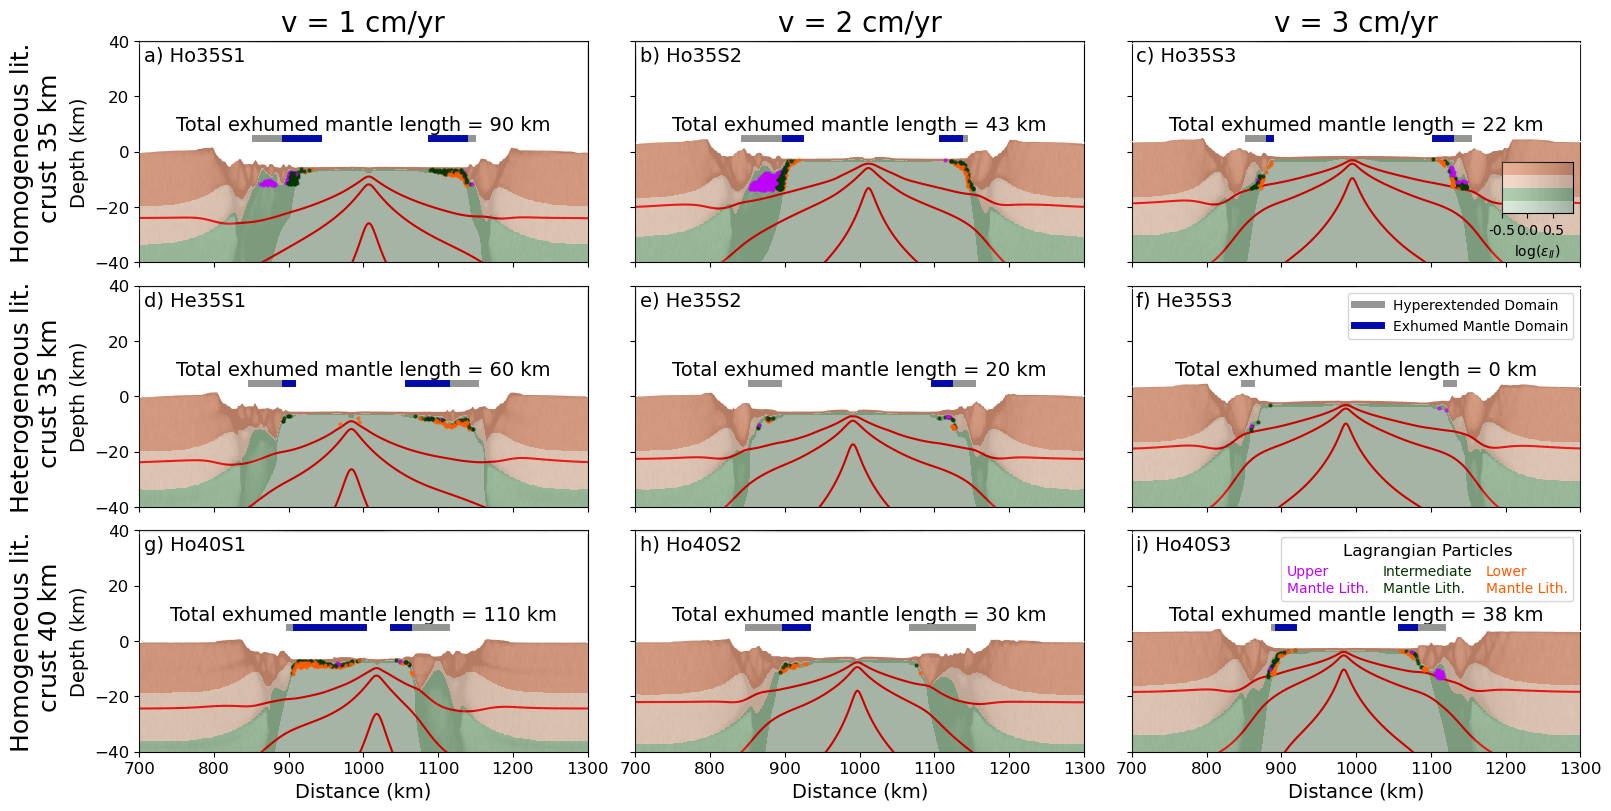

In [18]:
##############################################################################################################
#Set mandyoc property

# prop = 'density'
# prop = 'heat'
prop = 'lithology'
# prop = 'pressure'
# prop = 'strain'
# prop = 'strain_rate'
# prop = 'temperature'
# prop = 'temperature_anomaly'
# prop = 'viscosity'
# prop = 'surface'

extension_amount = 400.0e3 #m
instants = [np.round(extension_amount/(1/100)/1.0e6, 2), #(extension amount in m)/(velocity in m/yr)/1.0e6 to convert to Myr
            np.round(extension_amount/(2/100)/1.0e6, 2),
            np.round(extension_amount/(3/100)/1.0e6, 2)]*len(scenarios)

datasets_list = [dataset0, dataset1, dataset2, dataset3, dataset4, dataset5, dataset6, dataset7, dataset8]
trackdatasets_list = [trackdataset0, trackdataset1, trackdataset2, trackdataset3, trackdataset4, trackdataset5, trackdataset6, trackdataset7, trackdataset8]

plt.close('all')

fig_height = (3.0/2.0)*(len(instants)/3 + (0)) #6 minimum
fig = plt.figure(figsize=(16, 8), constrained_layout=True)

mosaic = """
         ABC
         DEF
         GHI
         """
axs = fig.subplot_mosaic(mosaic, gridspec_kw={'height_ratios':[0.5,
                                                               0.5,
                                                               0.5,
                                                              ]
                                             }
                        )

alphabet = list(string.ascii_uppercase)
axs_idxs = np.asarray(alphabet[0: len(scenarios)]) #starting at A subplot
idxs_aux = axs_idxs.reshape(int(len(scenarios)/3), 3)

xlims = [700, 1300]
ylims = [-40, 40]
topo_from_density = True
# topo_from_density = False
# plot_other_particles = True
plot_other_particles = False

color_lower_crust = 'xkcd:brown'
color_mlit_upper='xkcd:bright purple'#'xkcd:cerulean blue'
color_mlit_intermediate='xkcd:dark green'#'xkcd:scarlet'
color_mlit_lower='xkcd:bright orange'#'xkcd:dark green'

if(fig_to_plot=='Fig8'):
    box_position = tuple([0.84,#horizontal position respective to parent_bbox or "loc" position
                    0.72,# vertical position
                    0.16,# width
                    0.23])
else:
    box_position = tuple([0.84,#horizontal position respective to parent_bbox or "loc" position
                    0.19,# vertical position
                    0.16,# width
                    0.23])

for instant, dataset, trackdataset, ax_idx in zip(instants, datasets_list, trackdatasets_list, axs_idxs):
    idx = find_nearest(dataset.time, instant)
    plot_colorbar = True if ax_idx == axs_idxs[2] else False
    hcrust = 40.0e3 if ax_idx == 2 else 35.0e3 #m. Crustal thickness
    plot_property(dataset.isel(time=idx), prop, xlims, ylims, scenarios[0],
             fig,
             axs[ax_idx],
             print_time=False,
             plot_isotherms = plot_isotherms,
             topo_from_density=topo_from_density,
             plot_particles = False,
             particle_size = 0.2,
             particle_marker = ".",
             ncores = 20,
            #  step_plot = 4,
             isotherms = [500, 800, 1300],
             plot_colorbar=plot_colorbar,
             bbox_to_anchor=box_position,
            )
    plot_tracked_particles_depth_coded(trackdataset, axs[ax_idx], idx, hcrust=hcrust, markersize=4,
                                       plot_lower_crust_particles=False, plot_mantle_lithosphere_particles=True, plot_asthenosphere_particles=True,
                                       color_lower_crust=color_lower_crust, color_mlit_upper=color_mlit_upper, color_mlit_intermediate=color_mlit_intermediate, color_mlit_lower=color_mlit_lower)


#Drawing horizontal lines of margins domains
def plot_exhumed_domains(ax, x_left, x_right, z_bar,
                      color = 'xkcd:bright orange',
                      lw=5):

    #Exhumed mantle domain
    if(x_left[0] != x_left[1]):
        ax.plot(x_left, z_bar, color=color, lw=lw, zorder=90) #left
    
    if(x_right[0] != x_right[1]):
        ax.plot(x_right, z_bar, color=color, lw=lw, zorder=90) #right

z_bar = [5, 5]

if(clc==1):
    #Subplot A
    xhyperextendedA_left = [860, 970]
    xhyperextendedA_right  = [1140, 1160]
    xexhumedA_left = [970, 970]
    xexhumedA_right = [1140, 1140]
    #Subplot B
    xhyperextendedB_left = [850, 950]
    xhyperextendedB_right = [1125, 1155]
    xexhumedB_left = [950, 950]
    xexhumedB_right = [1125, 1125]
    #Subplot C
    xhyperextendedC_left = [840, 950]
    xhyperextendedC_right = [1125, 1160]
    xexhumedC_left = [950, 950]
    xexhumedC_right = [1125, 1125]


    #Subplot D
    xhyperextendedD_left = [850, 970]
    xhyperextendedD_right = [1120, 1165]
    xexhumedD_left = [970, 970]
    xexhumedD_right = [1120, 1120]
    #Subplot E
    xhyperextendedE_left = [845, 950]
    xhyperextendedE_right = [1120, 1165]
    xexhumedE_left = [950, 950]
    xexhumedE_right = [1120, 1120]
    #Subplot F
    xhyperextendedF_left = [850, 950]
    xhyperextendedF_right = [1120, 1175]
    xexhumedF_left = [950, 950]
    xexhumedF_right = [1120, 1120]


    #Subplot G
    xhyperextendedG_left = [860, 905]
    xhyperextendedG_right = [1000, 1090]
    xexhumedG_left = [905, 905]
    xexhumedG_right = [1000, 1000]
    #Subplot H
    xhyperextendedH_left = [870, 990]
    xhyperextendedH_right = [1085, 1120]
    xexhumedH_left = [990, 990]
    xexhumedH_right = [1085, 1085]
    #Subplot I
    xhyperextendedI_left = [860, 990]
    xhyperextendedI_right = [1085, 1120]
    xexhumedI_left = [990, 990]
    xexhumedI_right = [1085, 1085]

if(clc==10):
    #Subplot A
    xhyperextendedA_left = [855, 895]
    xhyperextendedA_right  = [1135, 1145]
    xexhumedA_left = [895, 940]
    xexhumedA_right = [1090, 1135]
    #Subplot B
    xhyperextendedB_left = [845, 900]
    xhyperextendedB_right = [1133, 1140]
    xexhumedB_left = [900, 920]
    xexhumedB_right = [1110, 1133]
    #Subplot C
    xhyperextendedC_left = [855, 883]
    xhyperextendedC_right = [1125, 1150]
    xexhumedC_left = [883, 885]
    xexhumedC_right = [1105, 1125]


    #Subplot D
    xhyperextendedD_left = [850, 895]
    xhyperextendedD_right = [1110, 1150]
    xexhumedD_left = [895, 905]
    xexhumedD_right = [1060, 1110]
    #Subplot E
    xhyperextendedE_left = [855, 890]
    xhyperextendedE_right = [1120, 1150]
    xexhumedE_left = [890, 890]
    xexhumedE_right = [1100, 1120]
    #Subplot F
    xhyperextendedF_left = [850, 860]
    xhyperextendedF_right = [1120, 1130]
    xexhumedF_left = [890, 890]
    xexhumedF_right = [1100, 1100]


    #Subplot G
    xhyperextendedG_left = [900, 910]
    xhyperextendedG_right = [1060, 1110]
    xexhumedG_left = [910, 1000]
    xexhumedG_right = [1040, 1060]
    #Subplot H
    xhyperextendedH_left = [850, 900]
    xhyperextendedH_right = [1070, 1150]
    xexhumedH_left = [900, 930]
    xexhumedH_right = [1070, 1070]
    #Subplot I
    xhyperextendedI_left = [890, 895]
    xhyperextendedI_right = [1078, 1115]
    xexhumedI_left = [895, 915]
    xexhumedI_right = [1060, 1078]

    # Calculate total lengths of exhumed mantle domains
    total_lengthA = np.diff(np.array(xexhumedA_right))[0] + np.diff(np.array(xexhumedA_left))[0]
    total_lengthB = np.diff(np.array(xexhumedB_right))[0] + np.diff(np.array(xexhumedB_left))[0]
    total_lengthC = np.diff(np.array(xexhumedC_right))[0] + np.diff(np.array(xexhumedC_left))[0]
    total_lengthD = np.diff(np.array(xexhumedD_right))[0] + np.diff(np.array(xexhumedD_left))[0]
    total_lengthE = np.diff(np.array(xexhumedE_right))[0] + np.diff(np.array(xexhumedE_left))[0]
    total_lengthF = np.diff(np.array(xexhumedF_right))[0] + np.diff(np.array(xexhumedF_left))[0]
    total_lengthG = np.diff(np.array(xexhumedG_right))[0] + np.diff(np.array(xexhumedG_left))[0]
    total_lengthH = np.diff(np.array(xexhumedH_right))[0] + np.diff(np.array(xexhumedH_left))[0]
    total_lengthI = np.diff(np.array(xexhumedI_right))[0] + np.diff(np.array(xexhumedI_left))[0]

    total_lengths = [total_lengthA, total_lengthB, total_lengthC, total_lengthD, total_lengthE, total_lengthF, total_lengthG, total_lengthH, total_lengthI]
color_necking = 'xkcd:dark brown'
color_hyperextended = 'xkcd:gray'
color_exhumed_mantle = 'xkcd:cobalt blue'#'xkcd:bright orange'
color_oceanic = 'xkcd:cobalt blue'
lw=5


plot_exhumed_domains(axs['A'], xhyperextendedA_left, xhyperextendedA_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['B'], xhyperextendedB_left, xhyperextendedB_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['C'], xhyperextendedC_left, xhyperextendedC_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['D'], xhyperextendedD_left, xhyperextendedD_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['E'], xhyperextendedE_left, xhyperextendedE_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['F'], xhyperextendedF_left, xhyperextendedF_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['G'], xhyperextendedG_left, xhyperextendedG_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['H'], xhyperextendedH_left, xhyperextendedH_right, z_bar, color=color_hyperextended)
plot_exhumed_domains(axs['I'], xhyperextendedI_left, xhyperextendedI_right, z_bar, color=color_hyperextended)


plot_exhumed_domains(axs['A'], xexhumedA_left, xexhumedA_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['B'], xexhumedB_left, xexhumedB_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['C'], xexhumedC_left, xexhumedC_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['D'], xexhumedD_left, xexhumedD_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['E'], xexhumedE_left, xexhumedE_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['F'], xexhumedF_left, xexhumedF_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['G'], xexhumedG_left, xexhumedG_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['H'], xexhumedH_left, xexhumedH_right, z_bar, color=color_exhumed_mantle)
plot_exhumed_domains(axs['I'], xexhumedI_left, xexhumedI_right, z_bar, color=color_exhumed_mantle)

#Bars labels
if(fig_to_plot=='Fig8'):
    ax_loc = 'F'
    axs[ax_loc].plot([-100, -100], [-100, -100], '-', color=color_hyperextended, lw=lw, zorder=90, label='Hyperextended Domain')
    axs[ax_loc].legend(loc='upper right', ncol=1, fontsize=10).set_zorder(90)

if(fig_to_plot=='Fig9'):
    ax_loc = 'F'
    axs[ax_loc].plot([-100, -100], [-100, -100], '-', color=color_hyperextended, lw=lw, zorder=90, label='Hyperextended Domain')
    axs[ax_loc].plot([-100, -100], [-100, -100], '-', color=color_exhumed_mantle, lw=lw, zorder=90, label='Exhumed Mantle Domain')
    axs[ax_loc].legend(loc='upper right', ncol=1, fontsize=10).set_zorder(90)

fsize = 14
##########################
#Set plot details
##########################
#Legend
idx_legend = 'I'
ax2 = axs[idx_legend].twinx()
ax2.axis('off')
# ax2.plot([-10,-10], [-10,-10], '-', color=color_lower_crust, markersize=5, label='Lower\nCrust')
if(fig_to_plot=='Fig8'):
    ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_upper, markersize=5, label='Upper\nMantle\nLithosphere')
    ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_intermediate, markersize=5, label='Intermediate\nMantle\nLithosphere')
    ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_lower, markersize=5, label='Lower\nMantle\nLithosphere')
    ax2.legend(loc='upper right', ncol=4, fontsize=10, handlelength=0, handletextpad=0, columnspacing=1.0,labelcolor='linecolor', title='Lagrangian Particles', title_fontsize=12)
if(fig_to_plot=='Fig9'):
    ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_upper, markersize=5, label='Upper\nMantle Lith.')
    ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_intermediate, markersize=5, label='Intermediate\nMantle Lith.')
    ax2.plot([-10,-10], [-10,-10], '-', color=color_mlit_lower, markersize=5, label='Lower\nMantle Lith.')
    ax2.legend(loc='upper right', ncol=4, fontsize=10, handlelength=0, handletextpad=0, columnspacing=1.0,labelcolor='linecolor', title='Lagrangian Particles', title_fontsize=12)
#Titles
xpos = 0.01
ypos = 0.91

line_labels = np.asarray(list(string.ascii_lowercase)[0: 9])
label_fsize = 14
if(fig_to_plot=='Fig8'):
    acronyms = ['Ho35W1', 'Ho35W2', 'Ho35W3',
                'He35W1', 'He35W2', 'He35W3',
                'Ho40W1', 'Ho40W2', 'Ho40W3']
if(fig_to_plot=='Fig9'):
    acronyms = ['Ho35S1', 'Ho35S2', 'Ho35S3',
                'He35S1', 'He35S2', 'He35S3',
                'Ho40S1', 'Ho40S2', 'Ho40S3']

for ax_idx, line_label, i in zip(axs_idxs, line_labels, range(len(axs_idxs))):
    axs[ax_idx].text(xpos, ypos, f"{line_label}) {acronyms[i]}", transform=axs[ax_idx].transAxes, fontsize=fsize, zorder=60)
    if(axs[ax_idx].get_subplotspec().is_first_col()):
        axs[ax_idx].set_ylabel('Depth (km)', fontsize=label_fsize)
    else:
        axs[ax_idx].set_yticklabels([])

    if(axs[ax_idx].get_subplotspec().is_last_row()):
        axs[ax_idx].set_xlabel('Distance (km)', fontsize=label_fsize)
    else:
        axs[ax_idx].set_xticklabels([])
    
    if(clc==10):
        total_length = total_lengths[i]
        axs[ax_idx].text(0.5, 0.62, f"Total exhumed mantle length = {total_length:.0f} km", transform=axs[ax_idx].transAxes, fontsize=14, zorder=60, ha='center', va='center')

xpos = -0.23
ypos = 0.5
axs['A'].text(xpos, ypos, f"Homogeneous lit.\n crust 35 km", transform=axs['A'].transAxes, fontsize=18, rotation=90, ha='center', va='center')
axs['D'].text(xpos, ypos, f"Heterogeneous lit.\n crust 35 km", transform=axs['D'].transAxes, fontsize=18, rotation=90, ha='center', va='center')
axs['G'].text(xpos, ypos, f"Homogeneous lit.\n crust 40 km", transform=axs['G'].transAxes, fontsize=18, rotation=90, ha='center', va='center')

xpos = 0.5
ypos = 1.08
axs['A'].text(xpos, ypos, f"v = 1 cm/yr", transform=axs['A'].transAxes, fontsize=20, ha='center', va='center')
axs['B'].text(xpos, ypos, f"v = 2 cm/yr", transform=axs['B'].transAxes, fontsize=20, ha='center', va='center')
axs['C'].text(xpos, ypos, f"v = 3 cm/yr", transform=axs['C'].transAxes, fontsize=20, ha='center', va='center')

if(fig_to_plot=='Fig8'):
    xpos = 0.55
    ypos = 0.54
    axs['D'].text(xpos, ypos, f"PREP", transform=axs['D'].transAxes, fontsize=10, ha='center', va='center', rotation=45, zorder=70)
    axs['D'].text(xpos+0.1, ypos, f"PREP", transform=axs['D'].transAxes, fontsize=10, ha='center', va='center', rotation=45, zorder=70)


figname = fig_to_plot
fig_format = 'jpeg'
print(f"Saving {fig_to_plot}.{fig_format}")
fig.savefig(f"figures/{fig_to_plot}.{fig_format}", dpi=300)

(1, 2, 3, 4)